In [14]:
import pandas as pd
import sys
import os
BASE_PATH = os.getcwd()
sys.path.append(BASE_PATH)

train_path = f"{BASE_PATH}/churn-prediction-25-26/train.parquet"
test_path  = f"{BASE_PATH}/churn-prediction-25-26/test.parquet"


#train = pd.read_parquet(train_path)
#test  = pd.read_parquet(test_path)

#print(df_train.shape)
#print(df_test.head())   
#print(df_train.columns)
#print(df_test.columns)

In [32]:
#print(df_train.head())

# Exploratory Data analylis

In [20]:
import polars as pl

train = pl.read_parquet(train_path)
test  = pl.read_parquet(test_path)


In [21]:
train.shape, test.shape


((17499636, 20), (4393179, 20))

In [22]:
train.columns
#train.dtypes

['status',
 'gender',
 'firstName',
 'level',
 'lastName',
 'userId',
 'ts',
 'auth',
 'page',
 'sessionId',
 'location',
 'itemInSession',
 'userAgent',
 'method',
 'length',
 'song',
 'artist',
 'time',
 'registration',
 '__index_level_0__']

In [23]:
train_users = train["userId"].n_unique()
test_users  = test["userId"].n_unique()


print(train["time"].max())
print(train["time"].min())


2018-11-20 00:00:00
2018-10-01 00:00:01


In [24]:
print(type(train))

<class 'polars.dataframe.frame.DataFrame'>


In [25]:
daily_counts = (
    train
    .with_columns(pl.col("time").dt.cast_time_unit("ms"))
    .with_columns(pl.col("time").dt.date().alias("date"))
    .group_by("date")
    .agg(pl.len().alias("count"))
    .sort("date")
)

daily_counts

date,count
date,u32
2018-10-01,365478
2018-10-02,405387
2018-10-03,405160
2018-10-04,436489
2018-10-05,413261
…,…
2018-11-16,358075
2018-11-17,227445
2018-11-18,198809


Text(0, 0.5, 'Number of Events')

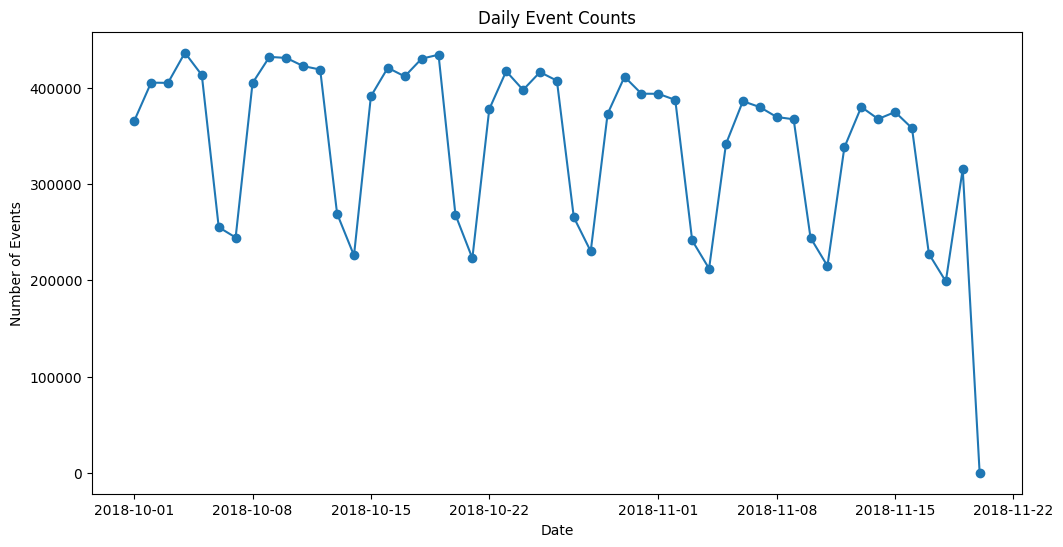

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(daily_counts["date"], daily_counts["count"], marker='o')
plt.title("Daily Event Counts")
plt.xlabel("Date")
plt.ylabel("Number of Events")

In [27]:
train['page'].value_counts().sort(by='count', descending=True)


page,count
str,u32
"""NextSong""",14291433
"""Thumbs Up""",789391
"""Home""",645259
"""Add to Playlist""",409606
"""Roll Advert""",284837
…,…
"""Error""",17294
"""Submit Upgrade""",11381
"""Submit Downgrade""",4425


In [28]:
print((train['page'] == "Cancellation Confirmation").sum())



4271
